In [229]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import itertools as it
import torch as pt
import tqdm
import pyproj as pp
import shapely.geometry as geom
from matplotlib import colormaps as cmaps
import matplotlib.colors as mcolors
import windrose as rose

import datetime as dt
from GDELTAnomalies.datasets.gdelt_pt_dataset import GDELTDataset

In [2]:
import os
import numpy as np
import pickle

In [7]:
wgs84 = pp.CRS.from_epsg(4326)
web = pp.CRS.from_epsg(3857)

In [ ]:
file_name = "plot_data/plot_isrpse_35_32.pkl"

with open(file_name, 'rb') as f:
    data1 = pickle.load(f)

In [ ]:
datadict = data1["ISR_18_35_32"]

In [17]:
data = pd.read_csv("sampledata.csv")

/tmp/ipykernel_2160894/2674561073.py:1: DtypeWarning: Columns (9,12,19,22,56) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("sampledata.csv")


Code for gridlines

In [18]:
geometry = gpd.points_from_xy(data["ActionGeo_Long"], data["ActionGeo_Lat"], crs=wgs84)

In [19]:
geodata = gpd.GeoDataFrame(data, geometry=geometry, crs=wgs84)
geodata2 = geodata.to_crs(web)

In [20]:
latmin = 19
latmax = 62.5
lonmin = 10
lonmax = 60

vert_lines = [10 + 10 * x for x in range(6)][1:-1]
h_lines = [19.5 + 5 * x for x in range(9)][1:]
h_lines2 = [17 + 10 * x for x in range(7)][1:]

hcycler = it.cycle(["horiz1", "horiz2"])
lines_list = [geom.LineString([(lonmin, x), (lonmax, x)]) for x in h_lines] + [geom.LineString([(x, latmin), (x, latmax)]) for x in vert_lines]
lines_list2 = [geom.LineString([(lonmin, x), (lonmax, x)]) for x in h_lines2] + [geom.LineString([(x, latmin), (x, latmax)]) for x in vert_lines]
grid = gpd.GeoDataFrame(data = [next(hcycler) for x in h_lines] + ["vert" for x in vert_lines], geometry=lines_list, crs=wgs84)
grid2 = gpd.GeoDataFrame(data = ["horiz" for x in h_lines2] + ["vert" for x in vert_lines], geometry=lines_list2, crs=wgs84)

Code for actual plots

In [217]:
def get_plottable(datadict) -> tuple:
    """Puts predictions into nice geopandas dataframes for easy plotting"""
    
    # Downsample dataset for ease of plotting
    downsampled = datadict["beta_shrink"][::40]
    
    # Split into country, event code, lon, lat
    colnames = datadict["selected_var_names"]
    splitcols = [x.item().split("_") for x in colnames]
    country, event_code, lonAvg, latAvg = zip(*splitcols)
    
    # Convert to numbers
    lonAvg = np.array([float(x) for x in lonAvg])
    latAvg = np.array([float(x) for x in latAvg])
    event_code = np.array([int(x) for x in event_code])
    country = np.array(country)

    poss_country = ["DEU", "ISR", "TUR", "RUS", "PSE"]

    lonMin = lonAvg - 5
    lonMax = lonAvg + 5
    latAvg[(latAvg % 10) == 8] -= 1
    latMin = latAvg - 2.5
    latMax = latAvg + 2.5
    
    lonAvg[country == poss_country[0]] -= 3.33333
    lonAvg[country == poss_country[1]] -= 1.66666
    lonAvg[country == poss_country[2]] += 0
    lonAvg[country == poss_country[3]] += 1.66666
    lonAvg[country == poss_country[4]] += 3.33333    

    pointgeom = []
    magnitude = []
    labels = []
    
    magnitude_agg = []
    pointgeom_agg = []
    labels_agg = []

    for i in range(len(lonAvg)):
        xmin = lonMin[i].item()
        xmax = lonMax[i].item()
        ymin = latMin[i].item()
        ymax = latMax[i].item()
        xmid = lonAvg[i].item()
        ymid = latAvg[i].item()

        pointgeom += [geom.Point(xmid, ymid)] * downsampled.shape[0]
        pointgeom_agg.append(geom.Point(xmid, ymid))
        labels += [colnames[i]] * downsampled.shape[0]
        magnitude += list(downsampled[:, i])
        magnitude_agg.append(np.sum(downsampled[:, i]))
        labels_agg.append(colnames[i])

    df = gpd.GeoDataFrame(np.array([magnitude, labels]).T, geometry=pointgeom, crs=wgs84)
    df_agg = gpd.GeoDataFrame(np.array([magnitude_agg, labels_agg]).T, geometry=pointgeom_agg, crs=wgs84)
    df[0] = df[0].astype("float")
    df[1] = df[1].astype("string")
    df_agg[0] = df_agg[0].astype("float")
    df_agg[1] = df_agg[1].astype("string")
    return df, df_agg

In [218]:
df, df_agg = get_plottable(datadict)

In [219]:
xx = df.geometry.x.to_numpy()
yy = df.geometry.y.to_numpy()

xx_agg = df_agg.geometry.x.to_numpy()
yy_agg = df_agg.geometry.y.to_numpy()

In [ ]:
geod = pp.Geod(ellps="WGS84")
isr_yval = 32
isr_xval = 35
az1, az2, distances = geod.inv(xx, yy, np.repeat(isr_xval, len(xx)), np.repeat(isr_yval, len(yy)))
az1_agg, az2_agg, distances_agg = geod.inv(xx_agg, yy_agg, np.repeat(isr_xval, len(xx_agg)), np.repeat(isr_yval, len(yy_agg)))

Counting each posterior sample:

Text(0.5, 1.0, 'Posterior Spatial Spillover Correlated with Assault Actions in Grid Cell 35/32 by Israel')

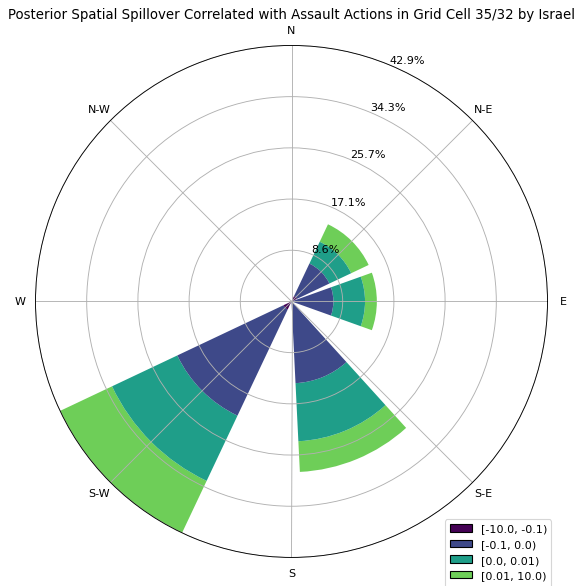

In [608]:
cmapv = plt.get_cmap("viridis", 10)
wraz = az2 + 180
wrax = rose.WindroseAxes.from_ax(figsize=(8, 8))
bins = (-10, -.1, 0, .01, 10)
hmm = wrax.bar(wraz, df[0], normed=True, cmap=cmapv, opening=1.75, bins=bins)
legend = wrax.legend(bbox_to_anchor = (0.8,-0.084), borderaxespad=0)
legend.get_patches()[4].set_visible(False)
yticks = []

# legend.set_clip_box(wrax.get_clip)
legend.set_clip_box(wrax.bbox)
for text in wrax.axes.get_yticklabels():
    text.set_text(text.get_text() + "%")
    yticks.append(text)
wrax.axes.set_yticklabels(yticks)
texts = [f"[{a}, {b})" for a, b in np.lib.stride_tricks.sliding_window_view(bins, 2)]
legend_text = legend.get_texts()
for i, text in enumerate(legend_text):
    text = text.get_text()
    if i < len(texts):
        legend_text[i].set_text(texts[i])
    else:
        legend_text[i].set_text("")
wrax.set_title("Posterior Spatial Spillover Correlated with Assault Actions in Grid Cell 35/32 by Israel")

Counting the posterior mean:

In [597]:
df_agg[0] / 80000

0   -0.000043
1    0.000109
2    0.000078
3   -0.000058
4    0.000090
5   -0.000290
6   -0.000004
Name: 0, dtype: float64

Text(0.5, 1.0, 'Posterior Mean Spatial Spillover Correlated with Assault Actions in Grid Cell 35/32 by Israel')

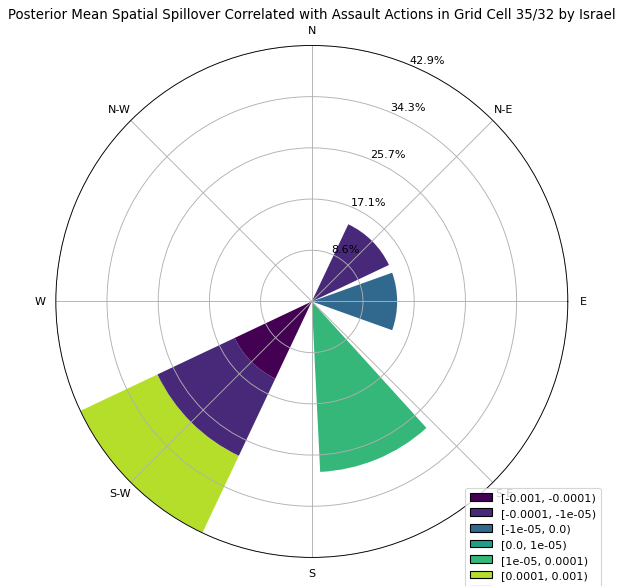

In [616]:
cmapv = plt.get_cmap("viridis", 10)
wraz_agg = az2_agg + 180
wrax = rose.WindroseAxes.from_ax(figsize=(8, 8))
bins2 = (-1e-3, -1e-4, -1e-5, 0, 1e-5, 1e-4, 1e-3)
hmm = wrax.bar(wraz_agg, df_agg[0] / 80000, normed=True, cmap=cmapv, opening=1.75, bins=bins2)
legend = wrax.legend(bbox_to_anchor = (0.8,-0.084), borderaxespad=0)
# legend.get_patches()[4].set_visible(False)
yticks = []

# legend.set_clip_box(wrax.get_clip)
legend.set_clip_box(wrax.bbox)
for text in wrax.axes.get_yticklabels():
    text.set_text(text.get_text() + "%")
    yticks.append(text)
wrax.axes.set_yticklabels(yticks)
texts = [f"[{a}, {b})" for a, b in np.lib.stride_tricks.sliding_window_view(bins2, 2)]
legend_text = legend.get_texts()
for i, text in enumerate(legend_text):
    text = text.get_text()
    if i < len(texts):
        legend_text[i].set_text(texts[i])
    else:
        legend_text[i].set_text("")
wrax.set_title("Posterior Mean Spatial Spillover Correlated with Assault Actions in Grid Cell 35/32 by Israel")

In [ ]:
dx = np.sin(az1_agg * np.pi / 180) * 1 * np.abs(df_agg[0])
dy = np.cos(az1_agg * np.pi / 180) * 1 * np.abs(df_agg[0])

Text(0.5, 1.0, 'Average Spatial Spillover Correlated with Assault Actions in Grid Cell 35/32 by Israel')

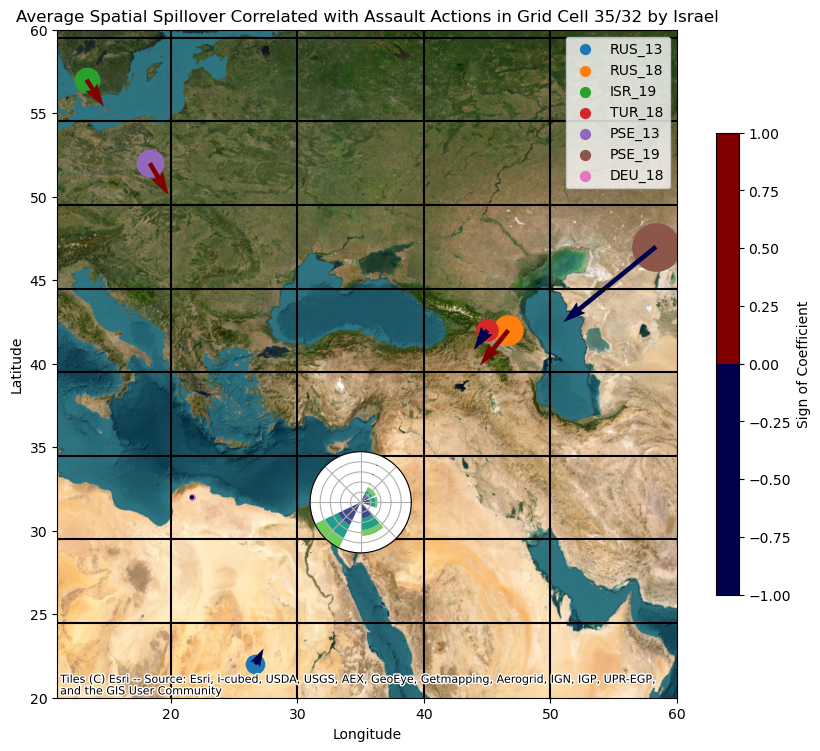

In [593]:
fig = plt.figure(figsize=(10, 12))

ax = fig.add_subplot(111)
for country in df_agg[1].str.split("_").apply(lambda x: "_".join((x[0], x[1]))).unique():
    subset_idxs = (df_agg[1].str.split("_").apply(lambda x: "_".join((x[0], x[1]))) == country).to_numpy()
    ax.scatter(xx_agg[subset_idxs], yy_agg[subset_idxs], s=np.abs(df_agg[0][subset_idxs]) * 50, label=country)

cmap = plt.get_cmap('seismic', 2)

quiver = ax.quiver(xx_agg, yy_agg, dx, dy, np.sign(df_agg[0]), scale=120, angles="xy", cmap=cmap)
cbar = fig.colorbar(quiver, shrink=0.5)
cbar.set_label("Sign of Coefficient")
ax.set_xlim(11, 60)
ax.set_ylim(20, 60)
fig.canvas.draw()
isr_bl = fig.transFigure.inverted().transform(ax.transData.transform((isr_xval - 4, isr_yval - 1)))
isr_tr = fig.transFigure.inverted().transform(ax.transData.transform((isr_xval + 4, isr_yval + 5)))

wrax = rose.WindroseAxes(fig, [isr_bl[0], isr_bl[1], isr_tr[0] - isr_bl[0], isr_tr[1] - isr_bl[1]])
wrax.bar(az2 + 180, df[0], normed=True, opening=1.75, bins=bins, cmap=cmapv)

for label in it.chain(wrax.get_xticklabels()):
    # Uncomment for better font visibility on rose labels if wanted
    # label.set_color("black")
    # label.set_fontweight(400)
    label.set_fontsize(0)
    # label.set_backgroundcolor("white")
for label in wrax.get_yticklabels():
    label.set_fontsize(0)

fig.add_axes(wrax)


legend = ax.legend()
for handle in legend.legend_handles:
    handle._sizes = [50]
grid.plot(ax=ax, color="black", label="Spatial Regions")
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, crs=wgs84, zoom=6)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Average Spatial Spillover Correlated with Assault Actions in Grid Cell 35/32 by Israel")

In [537]:
np.quantile(datadict["beta_shrink"], (0.025, 0.975), axis=0)

array([[-0.31159547, -0.03376251, -0.04090545, -0.07113725, -0.04533289,
        -0.77176709, -0.04192183],
       [ 0.31049119,  0.07075652,  0.06325622,  0.04735702,  0.08409414,
         0.71440506,  0.03980328]])

In [585]:
quantiles = np.quantile(datadict["beta_shrink"], (0.025, 0.975), axis=0)
print(f"{'Series':12}\t{'2.5%':6}\t{'97.5%':6}")
for x, lo, hi in zip(datadict["selected_var_names"], quantiles[0], quantiles[1]):
    print(f"{x:12}\t{lo:<.3f}\t{hi:<.3f}")

Series      	2.5%  	97.5% 
RUS_13_25_22	-0.312	0.310
RUS_18_45_42	-0.034	0.071
ISR_19_15_58	-0.041	0.063
TUR_18_45_42	-0.071	0.047
PSE_13_15_52	-0.045	0.084
PSE_19_55_48	-0.772	0.714
DEU_18_25_32	-0.042	0.040
